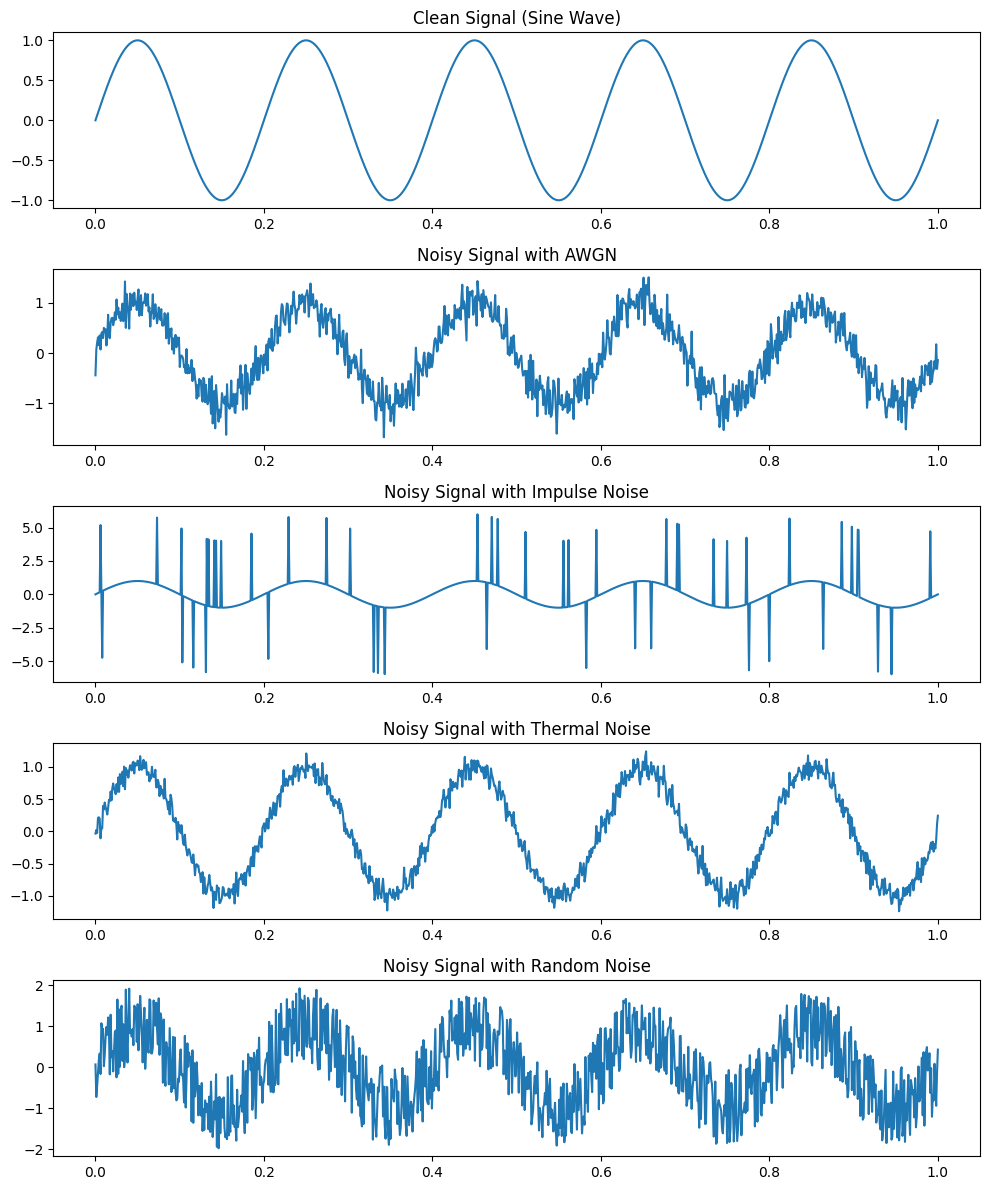

SNR AWGN: 9.83 dB
SNR Impulse: -3.79 dB
SNR Thermal: 16.85 dB
SNR Random: 1.81 dB


In [12]:
#Exp1_CommNoises.ipynb
import numpy as np
import matplotlib.pyplot as plt

# Simulate a clean signal (sine wave)
fs = 1000
t = np.linspace(0, 1, fs)
freq = 5
clean_signal = np.sin(2 * np.pi * freq * t)

# 1. AWGN Noise (Modified)
snr_db = 10  # Desired SNR in dB
signal_power = np.mean(clean_signal**2)
snr_linear = 10**(snr_db / 10)
noise_power = signal_power / snr_linear

awgn_noise = np.random.normal(0, np.sqrt(noise_power), fs)
noisy_signal_awgn = clean_signal + awgn_noise

# 2. Impulse Noise
impulse_noise = np.zeros(fs)
impulse_positions = np.random.randint(0, fs, size=50)
impulse_noise[impulse_positions] = np.random.choice([-5, 5], size=50)
noisy_signal_impulse = clean_signal + impulse_noise

# 3. Thermal Noise
thermal_noise = np.random.normal(0, 0.1, fs)
noisy_signal_thermal = clean_signal + thermal_noise

# 4. Random Noise
random_noise = np.random.uniform(-1, 1, fs)
noisy_signal_random = clean_signal + random_noise

# Plot
plt.figure(figsize=(10, 12))

plt.subplot(5, 1, 1)
plt.plot(t, clean_signal)
plt.title("Clean Signal (Sine Wave)")

plt.subplot(5, 1, 2)
plt.plot(t, noisy_signal_awgn)
plt.title("Noisy Signal with AWGN")

plt.subplot(5, 1, 3)
plt.plot(t, noisy_signal_impulse)
plt.title("Noisy Signal with Impulse Noise")

plt.subplot(5, 1, 4)
plt.plot(t, noisy_signal_thermal)
plt.title("Noisy Signal with Thermal Noise")

plt.subplot(5, 1, 5)
plt.plot(t, noisy_signal_random)
plt.title("Noisy Signal with Random Noise")

plt.tight_layout()
plt.show()

# SNR
def snr(signal, noise):
    return 10 * np.log10(np.var(signal) / np.var(noise))

print(f"SNR AWGN: {snr(clean_signal, awgn_noise):.2f} dB")
print(f"SNR Impulse: {snr(clean_signal, impulse_noise):.2f} dB")
print(f"SNR Thermal: {snr(clean_signal, thermal_noise):.2f} dB")
print(f"SNR Random: {snr(clean_signal, random_noise):.2f} dB")

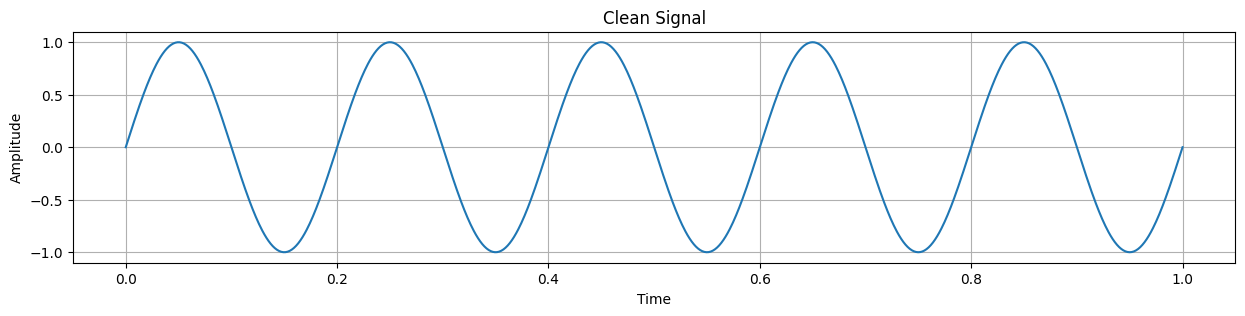

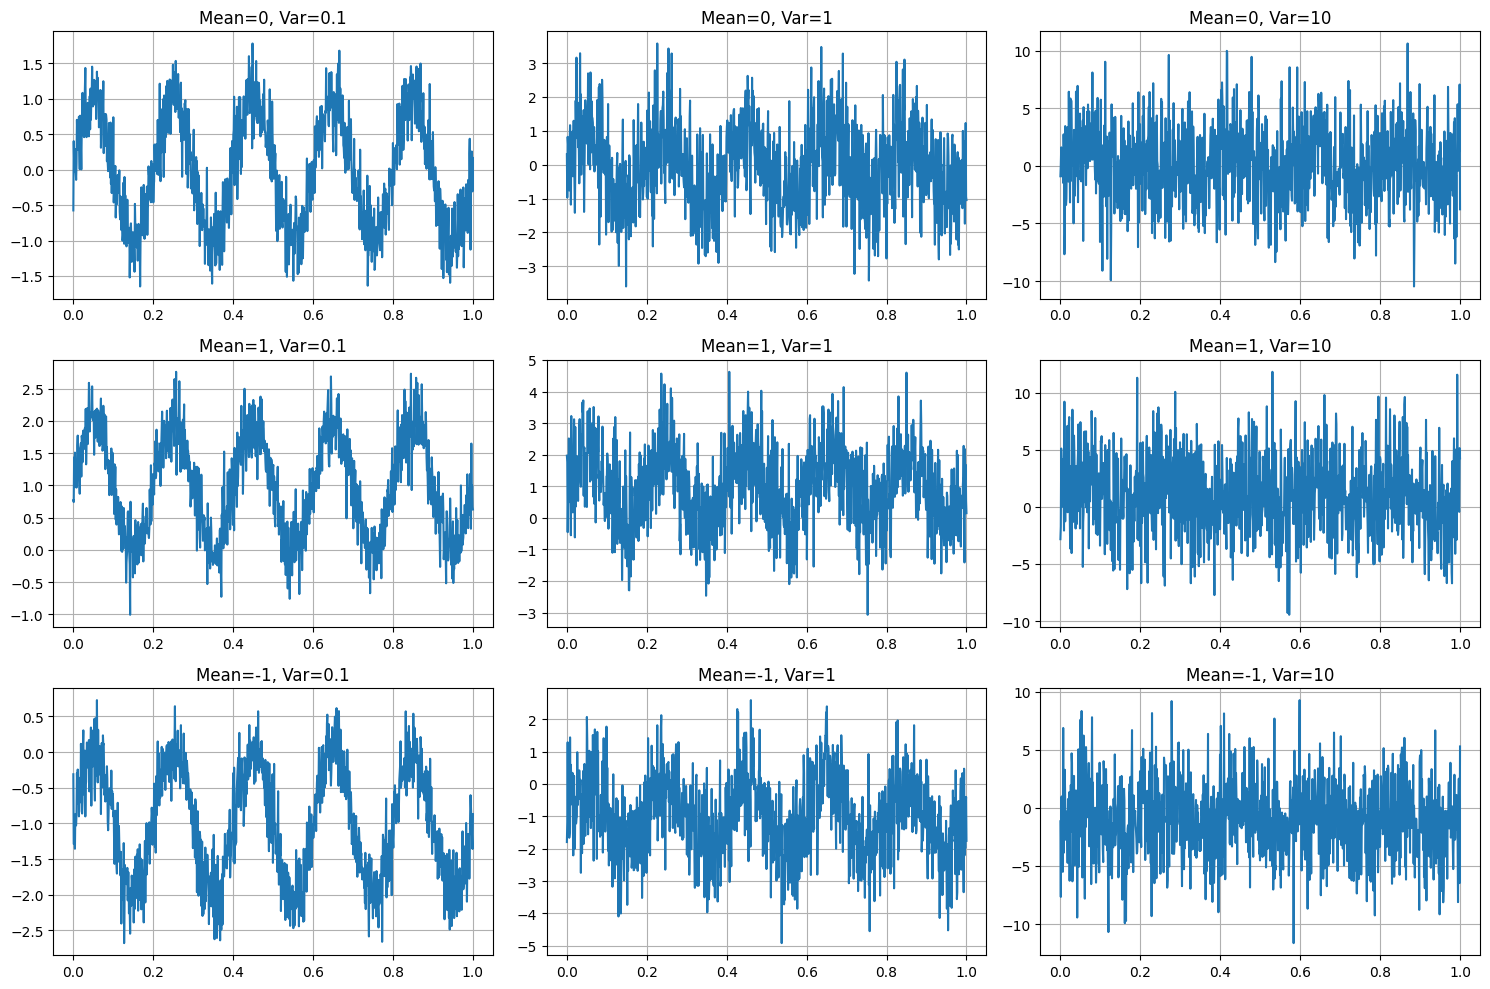


SNR Results (dB):
 Mean   Variance     SNR (dB)
------------------------------
    0        0.1         7.21
    0          1        -3.29
    0         10       -13.06
    1        0.1         7.08
    1          1        -3.12
    1         10       -13.38
   -1        0.1         7.24
   -1          1        -2.94
   -1         10       -13.00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a clean signal (a simple sine wave)
fs = 1000  # Sampling frequency
t = np.linspace(0, 1, fs)  # Time vector
freq = 5  # Frequency of the sine wave
clean_signal = np.sin(2 * np.pi * freq * t)

# Noise Characteristics
means = [0, 1, -1]  # Different means of noise
variances = [0.1, 1, 10]  # Different variances of noise

#Plot Clean Signal
plt.figure(figsize=(15,3))
plt.plot(t, clean_signal)
plt.title("Clean Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

#Plot Noise Signals in grid
fig, axes = plt.subplots(len(means),len(variances),figsize=(15,10))
snr_values={}

for i, mean in enumerate(means):
    for j, variance in enumerate (variances):
        noise = np.random.normal(mean, np.sqrt(variance),fs)
        noisy_signal = clean_signal + noise
        
        #Plot        
        axes[i,j].plot(t,noisy_signal)
        axes[i,j].set_title(f"Mean={mean}, Var={variance}")
        axes[i,j].grid()
        
        #SNR
        signal_power = np.var(clean_signal)
        noise_power = np.var(noise)
        snr=10*np.log10(signal_power/noise_power)
        snr_values[(mean,variance)] = snr
        
plt.tight_layout()
plt.show()

#Print SNR
print("\nSNR Results (dB):")
print(f"{'Mean':>5} {'Variance':>10} {'SNR (dB)':>12}")
print("-" * 30)

for (mean, variance), snr in snr_values.items():
    print(f"{mean:5} {variance:10} {snr:12.2f}")

Transmitted Data:  [1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 0 1
 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0
 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0]
Received Data:    [1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 0 1
 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0
 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0]


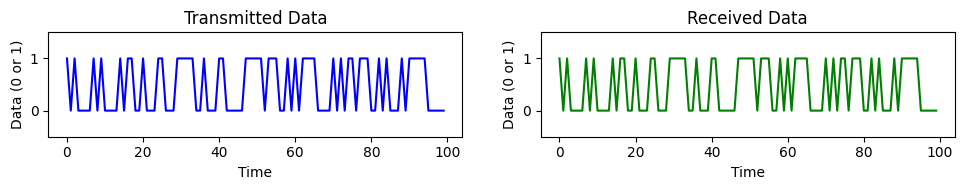

In [2]:
#Exp3_NoiselessBinary.ipynb
import numpy as np
import matplotlib.pyplot as plt

# Simulate a noiseless binary channel

# Step 1: Generate random binary data
data_length = 100  # Length of the binary data
transmitted_data = np.random.randint(0, 2, data_length)  # Generate random binary data (0s and 1s)

# Step 2: Simulate transmission over a noiseless channel
received_data = transmitted_data  # In a noiseless channel, transmitted and received data are the same

# Step 3: Display the transmitted and received data
print("Transmitted Data: ", transmitted_data)
print("Received Data:   ", received_data)

# Step 4: Visualize the data
plt.figure(figsize=(10, 2))
plt.subplot(1, 2, 1)
plt.plot(transmitted_data, label="Transmitted Data", color='blue')
plt.title("Transmitted Data")
plt.ylim(-0.5, 1.5)
plt.xlabel("Time")
plt.ylabel("Data (0 or 1)")

plt.subplot(1, 2, 2)
plt.plot(received_data, label="Received Data", color='green')
plt.title("Received Data")
plt.ylim(-0.5, 1.5)
plt.xlabel("Time")
plt.ylabel("Data (0 or 1)")

plt.tight_layout()
plt.show()

Channel Capacity of BSC with error probability 0.1: 0.5310 bits/channel use


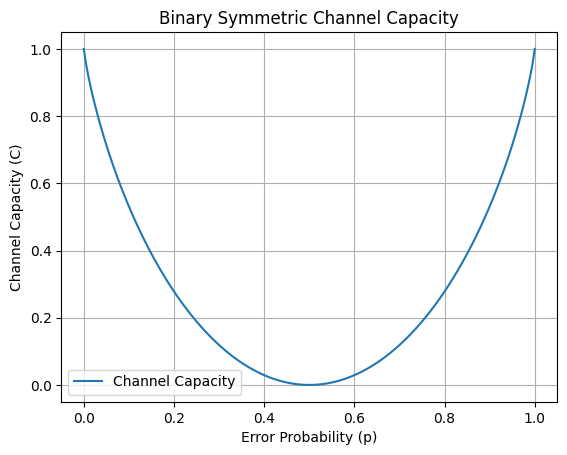

In [3]:
#Exp4_BinarySymmetricChannel.ipynb

import numpy as np
import matplotlib.pyplot as plt

# Binary entropy function
def binary_entropy(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Channel capacity function
def bsc_capacity(p):
    return 1 - binary_entropy(p)

# Input
p = float(input("Enter the probability of error (p) between 0 and 1: "))

# Validation
if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")

# Calculation
capacity = bsc_capacity(p)

print(f"Channel Capacity of BSC with error probability {p}: {capacity:.4f} bits/channel use")

# Plot
p_values = np.linspace(0, 1, 200)
capacity_values = bsc_capacity(p_values)

plt.plot(p_values, capacity_values, label="Channel Capacity")
plt.title("Binary Symmetric Channel Capacity")
plt.xlabel("Error Probability (p)")
plt.ylabel("Channel Capacity (C)")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# Shannon-Fano Coding Algorithm
# Step 1: Define the Shannon-Fano function

def shannon_fano(symbols, probabilities):
    # Base case
    if len(symbols) == 1:
        return {symbols[0]: ''}

    # Step 2: Sort symbols and probabilities in descending order
    sorted_indices = sorted(range(len(probabilities)), key=lambda k: probabilities[k], reverse=True)
    sorted_symbols = [symbols[i] for i in sorted_indices]
    sorted_probabilities = [probabilities[i] for i in sorted_indices]

    # Step 3: Divide into two parts
    total_probability = sum(sorted_probabilities)
    cumulative_probability = 0

    for i in range(len(sorted_probabilities)):
        cumulative_probability += sorted_probabilities[i]
        if cumulative_probability >= total_probability / 2:
            break

    left_symbols = sorted_symbols[:i+1]
    left_probabilities = sorted_probabilities[:i+1]
    right_symbols = sorted_symbols[i+1:]
    right_probabilities = sorted_probabilities[i+1:]

    # Step 4: Assign codes recursively
    code_dict = {}

    for symbol, code in shannon_fano(left_symbols, left_probabilities).items():
        code_dict[symbol] = '0' + code

    if right_symbols:
        for symbol, code in shannon_fano(right_symbols, right_probabilities).items():
            code_dict[symbol] = '1' + code

    return code_dict


# Step 5: Input the symbols and their corresponding probabilities
symbols = ['A', 'B', 'C', 'D', 'E']
probabilities = [0.4, 0.3, 0.2, 0.05, 0.05]

# Step 6: Call the Shannon-Fano function
codes = shannon_fano(symbols, probabilities)

# Step 7: Display result
print("Shannon-Fano Codes:")
print("Symbol\tProbability\tCode")

for i in range(len(symbols)):
    symbol = symbols[i]
    print(f"{symbol}\t{probabilities[i]}\t\t{codes[symbol]}")

Shannon-Fano Codes:
Symbol	Probability	Code
A	0.4		00
B	0.3		01
C	0.2		10
D	0.05		110
E	0.05		111


In [1]:
import heapq

def huffman_coding(data):
    heap = [[weight, [symbol, ""]] for symbol, weight in data.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)

        for pair in lo[1:]:
            pair[1] = '0' + pair[1]

        for pair in hi[1:]:
            pair[1] = '1' + pair[1]

        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

    return sorted(heapq.heappop(heap)[1:], key=lambda p: (len(p[1]), p))


data = {
    'A': .4,
    'B': .3,
    'C': .2,
    'D': .05,
    'E': .05
}

codes = huffman_coding(data)

print("Huffman Codes:")
print("Symbol\tFrequency\tCode")

code_dict = dict(codes)

for symbol in data:
    print(f"{symbol}\t{data[symbol]}\t\t{code_dict[symbol]}")

Huffman Codes:
Symbol	Frequency	Code
A	0.4		0
B	0.3		10
C	0.2		111
D	0.05		1100
E	0.05		1101
